In [1]:
import os 
from pathlib import Path
import shutil
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import re
from torchvision import transforms
from sklearn.model_selection import train_test_split
import json
from dataclasses import dataclass, asdict
import torch 
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp '/content/drive/MyDrive/Deep Learning Datasets /UTK FACE.zip' /content/
!unzip -q '/content/UTK FACE.zip' -d /content/local_dataset/

In [3]:
path = '/content/local_dataset/'
data= []
age_group = []
renamed_count = 0
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.jpg.chip.jpg'):
            old_name = os.path.join(root, file)
            new_name = file.replace('.chip.jpg', '')
            new_path = os.path.join(root,new_name)

            try:
                os.rename(old_name, new_path)
                renamed_count += 1
            except OSError as e:
                print(f"Error occurred while renaming {old_name}: {e}")
                
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(('.jpg','.jpeg','.png')):   
           match = re.match(r"(\d+)_", file)
           if match:
                age = int(match.group(1))
           if age <= 13:
                age_group.append(1) #1 == child
           elif age >13:
                age_group.append(0)    # 0 == adult  
           data.append(os.path.join(root, file))

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

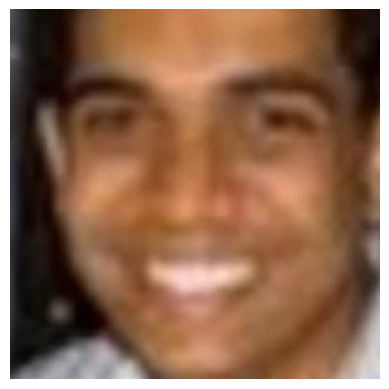

In [4]:
import sys
sys.path.append('/content/drive/My Drive/Deep Learning Models /UnderAgeFacePrivacy')
from Models import Custom_cnn
from Registry import yaml_loader, model_registry


sample_img = data[10]
opened_img = Image.open(sample_img)
opened_img.show()

plt.imshow(opened_img)
plt.axis('off')

In [5]:
class CustomDataset(Dataset):
    def __init__(self,data,label):
        self.data = data 
        self.label = label
        self.transform = transforms.Compose([transforms.Lambda(lambda img: img.convert('RGB')),
                                             transforms.Resize((224,224)),
                                             transforms.ToTensor(),
                                             transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])])
    def __len__(self):
        return len(self.data)
    def __getitem__ (self, idx):
        img_path = self.data[idx]
        img_label = self.label[idx]
        img = Image.open(img_path)
        img = self.transform(img)
        return img, img_label
    
def Accuracy(y_pred,y_true):
    y_pred = torch.argmax(y_pred, dim=1)
    correct = (y_pred == y_true).sum().item()
    total = len(y_true)
    accuracy = correct / total
    return accuracy


In [6]:
config_path = '/content/drive/My Drive/Deep Learning Models /UnderAgeFacePrivacy/config.yaml'
cfg = yaml_loader(config_path)
train_data, test_data, train_labels, test_labels = train_test_split(data, age_group, test_size = 0.2, random_state= 42)
data_train = CustomDataset(train_data,train_labels)
data_test = CustomDataset(test_data,test_labels)
Batch_size = cfg['training']['batch_size']
Num_worker = cfg['training']['num_worker']
train_dataloader  = DataLoader(data_train, batch_size = Batch_size, shuffle= True, num_workers=Num_worker, pin_memory= True)
test_dataloader = DataLoader(data_test, batch_size = Batch_size, shuffle= False, num_workers= Num_worker, pin_memory=True)

In [ ]:
model, input_size = model_registry(cfg)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= cfg['training']['learning_rate'])
epochs = cfg['training']['num_epochs']

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_accuracy = 0.0
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        running_accuracy += Accuracy(outputs, labels)
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_dataloader)
    epoch_accuracy = running_accuracy / len(train_dataloader)

    model.eval()
    with torch.no_grad():
        test_loss = 0.0
        test_accuracy = 0.0
        for images, labels in test_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            test_loss += loss.item()
            test_accuracy += Accuracy(outputs, labels)
    checkpoint = {'model_state_dict': model.state_dict(),
              'optimizer_state_dict': optimizer.state_dict(),
              'loss': epoch_loss,
              'epoch': epoch + 1 }
    model_save_path = '/content/drive/My Drive/Deep Learning Models /UnderAgeFacePrivacy/model.pt'
    torch.save(checkpoint, model_save_path)
    test_loss /= len(test_dataloader)
    test_accuracy/= len(test_dataloader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Test Loss: {test_loss:.4f}")
    print(f"Epoch [{epoch+1}/{epochs}], Accuracy: {epoch_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s] 


Epoch [1/20], Loss: 0.2242, Test Loss: 0.1779
Epoch [1/20], Accuracy: 0.9150, Test Accuracy: 0.9330
Epoch [2/20], Loss: 0.1831, Test Loss: 0.1615
Epoch [2/20], Accuracy: 0.9319, Test Accuracy: 0.9406
Epoch [3/20], Loss: 0.1743, Test Loss: 0.1754
Epoch [3/20], Accuracy: 0.9344, Test Accuracy: 0.9318
Epoch [4/20], Loss: 0.1711, Test Loss: 0.1772
Epoch [4/20], Accuracy: 0.9353, Test Accuracy: 0.9318
Epoch [5/20], Loss: 0.1691, Test Loss: 0.1584
Epoch [5/20], Accuracy: 0.9368, Test Accuracy: 0.9405
Epoch [6/20], Loss: 0.1666, Test Loss: 0.1561
Epoch [6/20], Accuracy: 0.9373, Test Accuracy: 0.9418
Epoch [7/20], Loss: 0.1666, Test Loss: 0.1545
Epoch [7/20], Accuracy: 0.9364, Test Accuracy: 0.9403
Epoch [8/20], Loss: 0.1631, Test Loss: 0.1586
Epoch [8/20], Accuracy: 0.9383, Test Accuracy: 0.9404
Epoch [9/20], Loss: 0.1650, Test Loss: 0.1496
Epoch [9/20], Accuracy: 0.9369, Test Accuracy: 0.9442


KeyboardInterrupt: 